# Music genre classification
The goal of this project is to extract the necessary features from the raw audio files, and use them to train the kNN, ANN and CNN models with it. After that, it could be compared to models that were trained with the dataset provided CSV files. Only 30 v 30 or also v 3?
- extracted audio features manually ✔     
- train kNN on extracted features   ✔       
    - train kNN on provided features ✔     
    - train kNN on provided features (3s) ✔
- train ANN on extracted features
    - train ANN on provided features
    - train ANN on provided features (3s)
- train CNN on provided spectrograms

### Importing GTZAN dataset

In [1]:
import os # to interact with OS: file/directory opeartions, envoronmental variables...
import platform
import pandas as pd # just, used to import the csvs. dataframe manipulation (csv/excel)

OS = platform.system()

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"        
os.environ["MKL_NUM_THREADS"] = "1"        
os.environ["NUMEXPR_NUM_THREADS"] = "1"   # these 4 were added to prevent the python kernel from dying when


In [2]:
MFCC_N = 14 # How may MFCC to keep (from 20)
# Path to Dataset
if OS == "Windows":
    PATH = "C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\genres_original"
    PATH_CSV_30 = "C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\features_30_sec.csv"
    PATH_CSV_3 = "C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\features_3_sec.csv"
    PATH_IMAGES = "C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original"
if OS == "Linux":
    PATH = "/home/ket/Documents/gtzan/archive/Data/genres_original"
    PATH_CSV_30 = "/home/ket/Documents/gtzan/archive/Data/features_30_sec.csv"
    PATH_CSV_3 = "/home/ket/Documents/gtzan/archive/Data/features_3_sec.csv"
    PATH_IMAGES = "/home/ket/Documents/gtzan/archive/Data/images_original"

In [3]:
# Import CSV and look at it
df_30 = pd.read_csv(PATH_CSV_30)
df_3 = pd.read_csv(PATH_CSV_3)
df_30.head(3)
df_30.tail(3)
# df_30.describe
#df_30.columns # 60 COLUMNS
# pandas quickstart: https://github.com/techwithtim/PanadasTutorial

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
997,rock.00097.wav,661794,0.432142,0.075268,0.081651,0.000322,2077.526598,231657.968040,1927.293153,74717.124394,...,33.597008,-12.845291,36.367264,3.440978,36.001110,-12.588070,42.502201,-2.106337,29.865515,rock
998,rock.00098.wav,661794,0.362485,0.091506,0.083860,0.001211,1398.699344,240318.731073,1818.450280,109090.207161,...,46.324894,-4.416050,43.583942,1.556207,34.331261,-5.041897,47.227180,-3.590644,41.299088,rock
999,rock.00099.wav,661794,0.358401,0.085884,0.054454,0.000336,1609.795082,422203.216152,1797.213044,120115.632927,...,59.167755,-7.069775,73.760391,0.028346,76.504326,-2.025783,72.189316,1.155239,49.662510,rock


In [4]:
# Pregled podatkov, any null values? 
# df_30.isnull().sum() # no null values
# df_30.info()

It appears that no data is missing
# Data preprocessing
The data set was imported, now it has to be determined which of the contained data, or rather clomuns, are relevant. There's 60 columns, let's take a look.
### What is needed
`filename` is not needed, can be removed, `label` has the genre . These three are needed because of the project description I wrote: MFCCs, ZCR, and Chroma features. But I see there's other features I will require like Spectral Centroids, Tempo and RMS (Root Mean Square).
Also do I need both avg and means? yea
### What is useful
`length`, `chroma_stft_mean`, `chroma_stft_var`, `rms_mean`
`rms_var`, `spectral_centroid_mean`, `spectral_centroid_var`,
`spectral_bandwidth_mean`, `spectral_bandwidth_var`, `rolloff_mean`,
`rolloff_var`, `zero_crossing_rate_mean`, `zero_crossing_rate_var`,
`harmony_mean`, `harmony_var`, `perceptr_mean`, `perceptr_var`, `tempo`
### What is not nedeed
`filename` and probably we could do without all the MFCCs. I remember 13 being enough.

In [5]:
# This code is reused below
# MFCC_N = 20
# col = df_30.pop("label")
# df_30.insert(0, "label", col)
# df_30.drop("filename", inplace=True, axis=1)
# # this loop removes as many MFCCs as defined at the top
# for n in range(20-MFCC_N):
#     name1 = f"mfcc{20-n}_var"
#     name2 = f"mfcc{20-n}_mean"
#     # print(name1, " and ", name2)
#     df_30.drop(name1, inplace=True, axis=1)
#     df_30.drop(name2, inplace=True, axis=1)
# df_30.columns



In [6]:
# check_csv = os.path.join(PATH,"/knn-data-df-30.csv")
check_csv = "knn-data-df-30.csv"
print(check_csv)
if not os.path.exists(check_csv):
    print("no exists")
else:
    print("exist")


knn-data-df-30.csv
exist


## Split Train & Test kNN - 30s

In [7]:
# https://www.geeksforgeeks.org/machine-learning/how-to-split-a-dataset-into-train-and-test-sets-using-python/
# https://pylearnai.com/machine-learning/csv-to-prediction-machine-learning-python/
# https://gao-hongnan.github.io/gaohn-galaxy/machine_learning/neighbours/k_nearest_neighbours/knn_feature_scaling.html 25.6.26
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from tqdm import tqdm

### variables
MFCC_N = 20
K_N = 30
TEST_SIZE = [0.1, 0.2, 0.3, 0.4]
RANDOM_STATE = [0, 42, 99]
CSV_PATH_KNN_30 = "knn-data-df-30.csv"
###


#omega loop to collect all the possible variations
if not os.path.exists(CSV_PATH_KNN_30):
    results = []

    df_base = df_30.copy()
    col = df_base.pop("label")
    df_base.insert(0, "label", col)
    df_base.drop("filename", inplace=True, axis=1)

    for i in tqdm(range(1, MFCC_N+1), desc="kNN Data collection progress"):       
        print("We're at MFCC: ", MFCC_N)
        df_work = df_base.copy()

        for n in range(20 - i):
            df_work.drop(f"mfcc{20-n}_var", inplace=True, axis=1)
            df_work.drop(f"mfcc{20-n}_mean", inplace=True, axis=1)

        X = df_work.drop(columns=["label"])
        y = df_work["label"]
        X_scaled = StandardScaler().fit_transform(X)

        for k in tqdm(range(1, K_N+1), desc="K-Neighbors", leave=False):      
            for test_size in tqdm(TEST_SIZE, desc="Test size", leave=False):
                for seed in tqdm(RANDOM_STATE, desc="seed", leave=False): 
                    
                    # col = df_work.pop("label")
                    # df_work.insert(0, "label", col)
                    # df_work.drop("filename", inplace=True, axis=1)        

                    X_train, X_test, y_train, y_test = train_test_split(
                        X_scaled, y, test_size=test_size, random_state=seed, stratify=y
                    )

                    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
                    acc = knn.score(X_test, y_test)

                    results.append({"MFCC_N": i, "K_N": k, "TEST_SIZE": test_size,
                                    "RANDOM_STATE": seed, "ACCURACY": acc})


    pd.DataFrame(results).to_csv(CSV_PATH_KNN_30, index=False)
print("File [", CSV_PATH_KNN_30,"] detected.")


File [ knn-data-df-30.csv ] detected.


After brief manual testing, the K that gave the best results was `K=10`, specifically with `MFCC_N=13`.
To the end of finding a combination of parametets that yield a higher accuracy, I automated some data collection - will be used later.
These were the parameters and their range of values:
`MFCC_N = [1-20]`
`K_N = [1-30]`
`TEST_SIZE = [0.1, 0.2, 0.3, 0.4]`
`RANDOM_STATE = [0, 42, 99]`


In [8]:
df_knn = pd.read_csv("knn-data-df-30.csv")
df_knn_sorted = df_knn.sort_values(by="ACCURACY", ascending=False)

df_knn_sorted.head(10)

,MFCC_N,K_N,TEST_SIZE,RANDOM_STATE,ACCURACY
6840,20,1,0.1,0,0.770
4717,14,4,0.1,42,0.770
4729,14,5,0.1,42,0.760
5092,15,5,0.2,42,0.755
4381,13,6,0.1,42,0.750
6864,20,3,0.1,0,0.750
3973,12,2,0.1,42,0.750
6206,18,8,0.1,99,0.750
4741,14,6,0.1,42,0.750
5089,15,5,0.1,42,0.750


## Feature extraction
In the project description I wrote that I would extract the needed features manually. To achieve that I will use the `AudioFeaturizer` library. The out put data is not 1:1 as the data provided by the dataset but it should do.
Crucial to note that one of the original audio files seems to be corrupted as it is simply not working, and there is nothing that can be extracted from it. The file in question is `jazz.00054.wav`.

In [9]:
# https://pypi.org/project/AudioFeaturizer/
from AudioFeaturizer.audio_featurizer import *
# just testing 
# test =audio_process("/home/ket/Documents/gtzan/archive/Data/genres_original/jazz/jazz.00055.wav")
# print(type(test))
# print("Genres: ", genres)

genres = os.listdir(PATH)
results = []

    # COMMENTED SO IT DOESNT EXTRACT FEATURES EVERY TIME
if not os.path.exists("extracted-features.csv"):
    for genre in tqdm(genres, desc="Feature exctraction"):
        genre_path = os.path.join(PATH, genre)
        for filename in os.listdir(genre_path):
            if(filename != "jazz.00054.wav"): # broken
                file_path = os.path.join(genre_path, filename)

                try:
                    features = audio_process(file_path)
                    row = features.iloc[0].to_dict()
                    row["genre"] = genre
                    row["filename"] = filename
                    results.append(row)
                except Exception as e:
                    print("[Error]: Something went wrong")

    extr_df = pd.DataFrame(results)
    extr_df.to_csv("extracted-features.csv", index=False)
print("File [extracted-features.csv] detected.")


File [extracted-features.csv] detected.


The audio features have now been extracted. As for the spectrograms, according to the project description the ones provided by the dataset will be used.
## Split Train & Test kNN - (extracted)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from tqdm import tqdm

### variables
MFCC_N = 20
K_N = 30
TEST_SIZE = [0.1, 0.2, 0.3, 0.4]
RANDOM_STATE = [0, 42, 99]
CSV_PATH_KNN_EXTR = "knn-extracted-features.csv"
###


#omega loop to collect all the possible variations
if not os.path.exists(CSV_PATH_KNN_EXTR):

    results = []

    df_base = extr_df.copy()
    col = df_base.pop("genre")
    df_base.insert(0, "genre", col)
    df_base.drop("filename", inplace=True, axis=1)
    #

    for i in tqdm(range(1, MFCC_N+1), desc="kNN Data collection progress"):       
        print("We're at MFCC: ", MFCC_N)
        df_work = df_base.copy()

        for n in range(20 - i):
            df_work.drop(f"mfcc{20-n}", inplace=True, axis=1)

        X = df_work.drop(columns=["genre"])
        y = df_work["genre"]
        X_scaled = StandardScaler().fit_transform(X)

        for k in tqdm(range(1, K_N+1), desc="K-Neighbors", leave=False):      
            for test_size in tqdm(TEST_SIZE, desc="Test size", leave=False):
                for seed in tqdm(RANDOM_STATE, desc="seed", leave=False): 
                    
                    # col = df_work.pop("label")
                    # df_work.insert(0, "label", col)
                    # df_work.drop("filename", inplace=True, axis=1)        

                    X_train, X_test, y_train, y_test = train_test_split(
                        X_scaled, y, test_size=test_size, random_state=seed, stratify=y
                    )

                    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
                    acc = knn.score(X_test, y_test)

                    results.append({"MFCC_N": i, "K_N": k, "TEST_SIZE": test_size,
                                    "RANDOM_STATE": seed, "ACCURACY": acc})


    pd.DataFrame(results).to_csv(CSV_PATH_KNN_EXTR, index=False)

print("File [", CSV_PATH_KNN_EXTR,"] detected.")


File [ knn-extracted-features.csv ] detected.


In [11]:
df_knn_ext = pd.read_csv("knn-extracted-features.csv")
df_knn_ext_sorted = df_knn.sort_values(by="ACCURACY", ascending=False)

df_knn_ext_sorted.head(10)

,MFCC_N,K_N,TEST_SIZE,RANDOM_STATE,ACCURACY
6840,20,1,0.1,0,0.770
4717,14,4,0.1,42,0.770
4729,14,5,0.1,42,0.760
5092,15,5,0.2,42,0.755
4381,13,6,0.1,42,0.750
6864,20,3,0.1,0,0.750
3973,12,2,0.1,42,0.750
6206,18,8,0.1,99,0.750
4741,14,6,0.1,42,0.750
5089,15,5,0.1,42,0.750


It would appear that the missing mean/avg columns in the extracted features does not impact accuracy at all, in fact the results are identical.
## Split Train & Test kNN - 3s

In [12]:
# ~22 minutes
### variables
MFCC_N = 20
K_N = 30
TEST_SIZE = [0.1, 0.2, 0.3, 0.4]
RANDOM_STATE = [0, 42, 99]
CSV_PATH_KNN_3 = "knn-data-df-3.csv"
# ###


# #omega loop to collect all the possible variations
if not os.path.exists(CSV_PATH_KNN_3):
    
    results = []

    df_base = df_3.copy()
    col = df_base.pop("label")
    df_base.insert(0, "label", col)
    df_base.drop("filename", inplace=True, axis=1)

    for i in tqdm(range(1, MFCC_N+1), desc="kNN Data collection progress"):       
        print("We're at MFCC: ", MFCC_N)
        df_work = df_base.copy()

        for n in range(20 - i):
            df_work.drop(f"mfcc{20-n}_var", inplace=True, axis=1)
            df_work.drop(f"mfcc{20-n}_mean", inplace=True, axis=1)

        X = df_work.drop(columns=["label"])
        y = df_work["label"]
        X_scaled = StandardScaler().fit_transform(X)

        for k in tqdm(range(1, K_N+1), desc="K-Neighbors", leave=False):      
            for test_size in tqdm(TEST_SIZE, desc="Test size", leave=False):
                for seed in tqdm(RANDOM_STATE, desc="seed", leave=False): 
                    
                    # col = df_work.pop("label")
                    # df_work.insert(0, "label", col)
                    # df_work.drop("filename", inplace=True, axis=1)        

                    X_train, X_test, y_train, y_test = train_test_split(
                        X_scaled, y, test_size=test_size, random_state=seed, stratify=y
                    )

                    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
                    acc = knn.score(X_test, y_test)

                    results.append({"MFCC_N": i, "K_N": k, "TEST_SIZE": test_size,
                                    "RANDOM_STATE": seed, "ACCURACY": acc})


    pd.DataFrame(results).to_csv(CSV_PATH_KNN_3, index=False)

print("File [", CSV_PATH_KNN_3,"] detected.")


File [ knn-data-df-3.csv ] detected.


In [13]:
df_knn_3 = pd.read_csv("knn-data-df-3.csv")
df_knn_3_sorted = df_knn.sort_values(by="ACCURACY", ascending=False)

df_knn_3_sorted.head(10)

,MFCC_N,K_N,TEST_SIZE,RANDOM_STATE,ACCURACY
6840,20,1,0.1,0,0.770
4717,14,4,0.1,42,0.770
4729,14,5,0.1,42,0.760
5092,15,5,0.2,42,0.755
4381,13,6,0.1,42,0.750
6864,20,3,0.1,0,0.750
3973,12,2,0.1,42,0.750
6206,18,8,0.1,99,0.750
4741,14,6,0.1,42,0.750
5089,15,5,0.1,42,0.750


Oddly enough - or maybe not - the songs being split into 3s to increase the amount of data 10 times did not change the results at all.

## CNN
Below the we are accessing the mel spectrograms of the audio files. The images need to be resized to be better suited for the CNN (150x150), and also normalize the pixels that got from 0-255 to stay in a 0-1 range.
The spectrogram of `jazz.00054.wav` is also missing.

In [14]:
# https://youtu.be/x_VrgWTKkiM?si=nk-_IoqJ3EoVed0t
# import importlib # this did not fix the tensorflow problem

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Source - https://stackoverflow.com/a/36898903
# Posted by L. Teder, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-02, License - CC BY-SA 4.0

genres = os.listdir(PATH) # da ne spacca scatole
image_paths = []
for root, dirs, files in os.walk(PATH_IMAGES):
    for name in files:
        image_paths.append(os.path.join(root, name))

print(image_paths, "\n")


X_images = []
y_labels = []


for image_path in tqdm(image_paths):
    img = load_img(image_path, target_size=(150,150)) # we shrink the image to consistent size for the CNN
    img_array = img_to_array(img)
    img_array = img_array / 255.0 # we need to scale pixels to be [0-1]
    X_images.append(img_array)
    y_labels.append(os.path.basename(os.path.dirname(image_path)))
        
X = np.array(X_images)
y = np.array(y_labels)

encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)
y_cat = to_categorical(y_enc)



['C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00000.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00001.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00002.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00003.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00004.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00005.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00006.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00007.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues00008.png', 'C:\\Users\\ket\\Desktop\\Jupyter-ML\\gtzan\\archive\\Data\\images_original\\blues\\blues0

100%|██████████| 999/999 [00:01<00:00, 845.04it/s]


### Train/test split

In [15]:
TEST_SIZE = [0.1, 0.2, 0.3, 0.4]
RANDOM_STATE = [0, 42, 99]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_enc
)

### Build model

In [16]:
# image augmentation - technique to stop from overfitting
model = models.Sequential([
    #convolute
    tf.keras.layers.Conv2D(64, (3,3), activation="relu", input_shape=(150,150,3)), # 3 is the number of channels (rgb) - (1 would be monochrome)
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),    
    # flatten results
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5), # also to help with overfitting
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax") # softmax layer, each neuron (10) lights up with a probability
])


c:\Users\ket\Desktop\Jupyter-ML\Jupyter-ML\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compiling model

In [17]:
model.compile(optimizer='adam', # try "rmsprop"
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,477,066 (13.26 MB)

 Trainable params: 3,477,066 (13.26 MB)

 Non-trainable params: 0 (0.00 B)

### Training model & evaluating model

In [18]:
# history = model.fit(
#     X_train,
#     y_train,
#     epochs=10,
#     batch_size=64,
#     validation_data=(X_test, y_test),
#     verbose=1)

# loss, acc = model.evaluate(X_test, y_test)
# print(f"Test accuracy: {acc:.4f}")

Parameters to change:
    - Convolutional blocks:
        - Number of Conv(2D) layers (2-4)
        - number of filters (32 -> 64 -> 128 -> 256)
        - kernel filter size, could try (5,5) if the images were large but generally (3,3) is good enough
    - Head
        - dense layer neurons, test 128, 256. (512 -> 256 -> 10) 
        - add some more dropout
    - Optimizer
        - "adam" is the default king, but could also try "rmsprop" which should be good on image spectrogram CNNs, or "sgd" with `momentum=0.9`
        - batch sizes 32, 64, 128
        - epochs, limit to at most 15,, but once the good settings have been found it can be trained for 30-50


In [19]:
# import tensorflow as tf
# from tensorflow import keras
# import matplotlib.pyplot as plt
# from tensorflow.keras import layers, models
# from tensorflow.keras.preprocessing.image import load_img, img_to_array
# import numpy as np
# from sklearn.preprocessing import LabelEncoder
# from tensorflow.keras.utils import to_categorical



# ### -----------------------------
# TEST_SIZE = [0.2, 0.3] # [0.1, 0.2, 0.3, 0.4]
# RANDOM_STATE = [42] #[0, 42, 99]
# #
# INPUT_SIZE = [150,200,288]
# #
# N_LAYERS = [2,3,4]
# DENSITY = [256, 512]
# DROPOUT = [True, False]
# DROPOUT_N = [0.25, 0.5]
# PADDING = ["valid", "same"]
# #
# BATCH_SIZE = [32, 64, 128]
# OPTIMIZER = ["adam", "rmsprop"]
# EPOCHS = 10
# results = []
# ### -----------------------------


# # Source - https://stackoverflow.com/a/36898903
# # Posted by L. Teder, modified by community. See post 'Timeline' for change history
# # Retrieved 2026-07-02, License - CC BY-SA 4.0


# # get images via path
# genres = os.listdir(PATH)
# image_paths = []
# for root, dirs, files in os.walk(PATH_IMAGES):
#     for name in files:
#         image_paths.append(os.path.join(root, name))

# print(image_paths, "\n")


# X_images = []
# y_labels = []

# # move to numpy arrays,
# for image_path in tqdm(image_paths):
#     img = load_img(image_path, target_size=(input_size,input_size)) # shrink the image to consistent size for the CNN
#     img_array = img_to_array(img)
#     img_array = img_array / 255.0 # to scale pixels to be [0-1]
#     X_images.append(img_array)
#     y_labels.append(os.path.basename(os.path.dirname(image_path)))
        
# X = np.array(X_images)
# y = np.array(y_labels)

# encoder = LabelEncoder()
# y_enc = encoder.fit_transform(y)
# y_cat = to_categorical(y_enc)



# for test_size in tqdm(TEST_SIZE):
#     for rand_state in RANDOM_STATE:
        
#         X_train, X_test, y_train, y_test = train_test_split(
#             X, y_cat, test_size=test_size, random_state=rand_state, stratify=y_enc
#         )

#         for input_size in INPUT_SIZE:   
#             for n_of_layers in N_LAYERS:
#                 for density in DENSITY:
#                     for optimizer in OPTIMIZER:
#                         for batch in BATCH_SIZE:
#                             for padding in PADDING:
#                                 for droupout in DROPOUT:
#                                     for dropout_n in DROPOUT_N:

#                                         ## SPLIT TRAIN/TEST

#                                         # borger
#                                         # TOP BUN
#                                         model_layers = [
#                                             tf.keras.layers.Conv2D(32, (3,3), activation="relu",
#                                                                    padding=padding,
#                                                                    input_shape=(input_size,input_size,3)), # 3 is the number of channels (rgb) - (1 would be monochrome)
#                                             tf.keras.layers.MaxPooling2D(2,2)
#                                             ]
#                                         if dropout == True:
#                                             model_layers.append(tf.keras.layers.Dropout(dropout_n))
#                                         model_layers.extend(
#                                             tf.keras.layers.Conv2D(64, (3,3), activation="relu",
#                                                                    padding=padding),
#                                             tf.keras.layers.MaxPooling2D(2,2)
#                                             )
#                                         if dropout == True:
#                                             model_layers.append(tf.keras.layers.Dropout(dropout_n))


#                                         # PATTIES
#                                         if n_of_layers >= 3:
#                                             model_layers.extend(
#                                                 tf.keras.layers.Conv2D(128, (3,3), activation="relu",
#                                                                        padding=padding),
#                                                 tf.keras.layers.MaxPooling2D(2,2)
#                                             )
#                                             if dropout == True:
#                                                 model_layers.append(tf.keras.layers.Dropout(dropout_n))
#                                             if n_of_layers >= 4:
#                                                 model_layers.extend(
#                                                 tf.keras.layers.Conv2D(256, (3,3), activation="relu", padding=padding),
#                                                 tf.keras.layers.MaxPooling2D(2,2)
#                                             )
#                                                 if dropout == True:
#                                                     model_layers.append(tf.keras.layers.Dropout(dropout_n))



#                                         # BOTTOM BUN
#                                         model_layers.extend(
#                                             tf.keras.layers.Flatten(),
#                                             tf.keras.layers.Dense(density, activation="relu"))
#                                         if dropout == True:
#                                             model_layers.append(tf.keras.layers.Dropout(dropout_n))
#                                         model_layers.append(    
#                                             tf.keras.layers.Dense(10, activation="softmax") # softmax layer, each neuron (10) lights up with a probability
#                                         )

                                       
#                                         # COMPILE
#                                         tf.keras.Sequential(model_layers)
#                                         model.compile(optimizer=optimizer, # try "rmsprop"
#                                                     loss='categorical_crossentropy',
#                                                     metrics=['accuracy'])
#                                         # model.summary()

#                                         # FIT
#                                         history = model.fit(
#                                             X_train,
#                                             y_train,
#                                             epochs=EPOCHS,
#                                             batch_size=batch,
#                                             validation_data=(X_test, y_test),
#                                             verbose=0)

#                                         loss, acc = model.evaluate(X_test, y_test, verbose =0)
#                                         # print(f"Test accuracy: {acc:.4f}")
#                                         results.append({
#                                             "INPUT_SIZE": input_size,
#                                             "TEST_SIZE": test_size,
#                                             "RANDOM_STATE" : rand_state,
#                                             "N_OF_LAYERS": n_of_layers,
#                                             "DENSITY" : density,
#                                             "optimizer": optimizer,
#                                             "BATCH_SIZE": batch,
#                                             "PADDING": padding,
#                                             "DROPOUT": dropout,
#                                             "DROPOUT_N": dropout_n,
#                                             "EPOCHS": epochs,
#                                             "LOSS": loss,
#                                             "ACCURACY": acc,
#                                         })


At this point I learn about `ParameterSampler` from `sklearn.model_selection`, in ceprav se mi ne da I will redo the above thing with it.
Here I was also trying to use CUDA to speed up the training, spent too much time trying to get this to work and cursing at windows so I gave up.

In [20]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs Available: ", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
GPUs Available:  []


In [21]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split, ParameterSampler
from tqdm import tqdm
from sklearn.model_selection import ParameterSampler

param_grid = {
    "input_size": [150, 200, 288],
    "test_size": [0.1, 0.2, 0.3, 0.4],
    "random_state": [0, 42, 99],
    "n_layers": [2, 3, 4],
    "density": [256, 512],
    "optimizer": ["adam", "rmsprop"],
    "batch_size": [32, 64, 128],
    "padding": ["valid", "same"],
    "dropout": [True, False],
    "dropout_n": [0.25, 0.5],
}

EPOCHS = 10
N_TRIALS = 50
CSV_PATH_CNN = "cnn-data.csv"  
sampled_params = list(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=42))

image_cache = {} # to not reload/recomopute the same imge in a different size every time a parameter changes

# making a function - whaaaa no way, unheard of in python
if not os.path.exists(CSV_PATH_CNN):
    def load_images_at_size(input_size):
        if input_size in image_cache:
            return image_cache[input_size]
        X_images = []
        for image_path in image_paths:
            img = load_img(image_path, target_size=(input_size, input_size))
            X_images.append(img_to_array(img) / 255.0) # to normalize
        X = np.array(X_images)
        y_cat_local = to_categorical(y_enc)
        image_cache[input_size] = (X, y_cat_local)
        return X, y_cat_local


    sampled_params = sorted(sampled_params, key=lambda d: d["input_size"])

    for params in tqdm(sampled_params):
        X, y_cat = load_images_at_size(params["input_size"])

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_cat, test_size = params["test_size"],
            random_state=params["random_state"],
            stratify = y_enc
        )        


        model_layers = [
            tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding=params["padding"],
                                input_shape = (params["input_size"], params["input_size"], 3)),
            tf.keras.layers.MaxPool2D(2,2),                               
        ]

        if params["dropout"]:
            model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))
        
        model_layers.extend([
            tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding = params["padding"]),
            tf.keras.layers.MaxPooling2D(2,2),
        ])

        if params["dropout"]:
            model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))

        if params["n_layers"] >= 3: ### 3rd layer
            model_layers.extend([
                tf.keras.layers.Conv2D(128, (3,3), activation = "relu", padding = params["padding"]),
                tf.keras.layers.MaxPooling2D(2,2),
            ])
            if params["dropout"]:
                model_layers.append(keras.layers.Dropout(params["dropout_n"]))

        if params["n_layers"] >= 4: ### 4th layer
            model_layers.extend([
            tf.keras.layers.Conv2D(128, (3,3), activation = "relu", padding = params["padding"]),
            tf.keras.layers.MaxPooling2D(2,2),
        ])
            if params["dropout"]:
                model_layers.append(keras.layers.Dropout(params["dropout_n"]))
        
        model_layers.append(tf.keras.layers.Flatten())
        model_layers.append(tf.keras.layers.Dense(params["density"], activation="relu"))
        
        if params["dropout"]:
            model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))
        
        model_layers.append(tf.keras.layers.Dense(10, activation = "softmax"))
        model = tf.keras.Sequential(model_layers)
        model.compile(optimizer=params["optimizer"],
                    loss = "categorical_crossentropy",
                    metrics = ["accuracy"])
        
        model.fit(X_train, y_train, epochs = EPOCHS, batch_size = params["batch_size"],
                validation_data = (X_test, y_test,), verbose = 0)

        loss, acc = model.evaluate(X_test, y_test, verbose =0)

        results.append({**params, "EPOCHS": EPOCHS, "LOSS": loss, "ACCURACY": acc})

        pd.DataFrame(results).to_csv("cnn-data.csv", index = False)
print("File [", CSV_PATH_CNN,"] detected.")








File [ cnn-data.csv ] detected.


We can see the results below are currently not as high as the KNN - so what I'll do is take the parameters of the first 2 or 3 and train them further, with some 30 epochs.

In [22]:
df_cnn = pd.read_csv("cnn-data.csv")
df_cnn_sorted = df_cnn.sort_values(by="accuracy", ascending=False)

df_cnn_sorted.head(10)

,test_size,random_state,padding,optimizer,n_layers,input_size,dropout_n,dropout,density,batch_size,epochs,loss,accuracy
41,0.1,0,same,adam,3,288,0.25,False,512,64,10,1.133983,0.6600
22,0.4,99,valid,adam,2,200,0.25,False,512,32,10,1.367847,0.6300
23,0.2,99,same,rmsprop,2,200,0.25,True,256,32,10,1.128419,0.6050
39,0.1,99,valid,rmsprop,2,288,0.25,False,256,32,10,1.284930,0.6000
49,0.2,99,valid,adam,2,288,0.50,False,512,128,10,1.237455,0.5750
37,0.4,99,valid,adam,2,288,0.50,False,256,64,10,1.472354,0.5675
40,0.2,0,valid,rmsprop,3,288,0.50,False,512,32,10,1.640918,0.5550
35,0.2,42,valid,adam,4,288,0.50,False,256,32,10,1.278495,0.5500
14,0.1,99,same,adam,2,150,0.25,False,512,32,10,1.425878,0.5500
45,0.3,0,valid,adam,3,288,0.25,False,256,64,10,1.415665,0.5500


In [23]:
# # test_size	random_state	padding	    optimizer	n_layers	input_size	dropout_n	dropout	density	batch_size	epochs	loss	  accuracy
# # 0.1	        0            same         adam	      3	        288	            0.25	False	512	        64	       10	1.133983	0.660
# # 0.4	        99	        valid	       adam       2	        200	            0.25	False	512	        32	       10	1.367847	0.630
# # 0.2       	99	         same	    rmsprop	      2	        200	            0.25	True	256	        32	       10	1.128419	0.605
# # 0.3	        0	        valid	      adam	      3	        288	            0.25	False	256	        64	       10	1.415665	0.5500

# #model-1#test_size = 0.1; random_state = 0; padding = "same"; optimizer = "adam"; n_layers= 3; input_size = 288; dropout_n = 0.25; dropout = False; density = 512; batch_size =64; EPOCHS = 30
# #model-2#test_size = 0.4; random_state = 99; padding = "valid"; optimizer = "adam"; n_layers= 2; input_size = 200; dropout_n = 0.25; dropout = False; density = 512; batch_size =32; EPOCHS = 30
# #model-3#test_size = 0.2; random_state = 99; padding = "same"; optimizer = "rmsprop"; n_layers= 2; input_size = 200; dropout_n = 0.25; dropout = True; density = 256; batch_size =32; EPOCHS = 30
# #model-4#test_size = 0.3; random_state = 42; padding = "valid"; optimizer = "rmsprop"; n_layers= 3; input_size = 200; dropout_n = 0.50; dropout = True; density = 256; batch_size =64; EPOCHS = 30
# #model-5#test_size = 0.3; random_state = 0; padding = "valid"; optimizer = "adam"; n_layers= 3; input_size = 288; dropout_n = 0.25; dropout = False; density = 256; batch_size =64; EPOCHS = 30



# def load_images_at_size(input_size):
#     if input_size in image_cache:
#         return image_cache[input_size]
#     X_images = []
#     for image_path in image_paths:
#         img = load_img(image_path, target_size=(input_size, input_size))
#         X_images.append(img_to_array(img) / 255.0) # to normalize
#     X = np.array(X_images)
#     y_cat_local = to_categorical(y_enc)
#     image_cache[input_size] = (X, y_cat_local)
#     return X, y_cat_local

# X, y_cat = load_images_at_size(input_size)

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y_cat, test_size = test_size,
#     random_state=random_state,
#     stratify = y_enc
# )



# model_layers = [
#     tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding=padding,
#                         input_shape = (input_size, input_size, 3)),
#     tf.keras.layers.MaxPool2D(2,2),                               
# ]

# if dropout:
#     model_layers.append(tf.keras.layers.Dropout(dropout_n))

# model_layers.extend([
#     tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding = padding),
#     tf.keras.layers.MaxPooling2D(2,2),
# ])

# if dropout:
#     model_layers.append(tf.keras.layers.Dropout(dropout_n))

# if n_layers >= 3: ### 3rd layer
#     model_layers.extend([
#         tf.keras.layers.Conv2D(128, (3,3), activation = "relu", padding = padding),
#         tf.keras.layers.MaxPooling2D(2,2),
#     ])
#     if dropout:
#         model_layers.append(keras.layers.Dropout(dropout_n))

# if n_layers >= 4: ### 4th layer
#     model_layers.extend([
#     tf.keras.layers.Conv2D(128, (3,3), activation = "relu", padding = padding),
#     tf.keras.layers.MaxPooling2D(2,2),
# ])
#     if dropout:
#         model_layers.append(keras.layers.Dropout(dropout_n))

# model_layers.append(tf.keras.layers.Flatten())
# model_layers.append(tf.keras.layers.Dense(density, activation="relu"))

# if dropout:
#     model_layers.append(tf.keras.layers.Dropout(dropout_n))

# model_layers.append(tf.keras.layers.Dense(10, activation = "softmax"))
# model = tf.keras.Sequential(model_layers)
# model.compile(optimizer=optimizer,
#             loss = "categorical_crossentropy",
#             metrics = ["accuracy"])

# history = model.fit(X_train, y_train, epochs = EPOCHS, batch_size = batch_size,
#         validation_data = (X_test, y_test,), verbose = 1)

# loss, acc = model.evaluate(X_test, y_test, verbose =1)


Plotting the models' performance to see if they're overfitting. And yes they do seem to overfit 

In [24]:
# Printing graphs to vizualize overitting
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history['accuracy']) + 1)

config_str = (
    "test_size = 0.3, random_state = 42, padding = \"valid\", optimizer = \"rmsprop\", "
     "n_layers= 3, input_size = 200, dropout_n = 0.50, "
     "dropout = True, density = 256, batch_size =64, EPOCHS = 30"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history.history['accuracy'], label='Train Accuracy')
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_title('Accuracy over Epochs')

axes[1].plot(epochs_range, history.history['loss'], label='Train Loss')
axes[1].plot(epochs_range, history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].set_title('Loss over Epochs')

# main title
fig.suptitle('Model Performance', fontsize=13, fontweight='bold')

# config caption underneath, small and unobtrusive
fig.text(0.5, -0.02, config_str, ha='center', va='top', fontsize=8, color='gray', wrap=True)

plt.tight_layout()
plt.savefig("cnn-model-5.png", bbox_inches='tight', dpi=150)  # bbox_inches='tight' keeps the caption from getting cut off
plt.show()

NameError: name 'history' is not defined

# ANN
Artificial Neural Networks (ANNs) are composed from layers of nodes (neurons), where each node processes information and passes it to the next layer. TensorFlow, an open-source machine learning framework developed by Google, provides a useful environment for implementing and training ANNs. - GeeksForGeeks

"adam" is an implementation of backpropagation.

In [ ]:
# df_30.head()
# df_3.head()
from sklearn.model_selection import ParameterSampler
### Vars
param_grid = {
    "test_size": [0.2, 0.3, 0.4],
    "random_state": [0, 42, 99],
    "n_layers": [2, 3, 4],
    "neuro_1": [128, 256, 512],
    "neuro_2": [64, 128, 256],
    "neuro_3": [32, 64, 128],
    "neuro_4": [16, 32, 64],
    "dropout": [True, False],
    "dropout_n": [0.25, 0.5],
    "batch_size": [32, 64, 128],
    "optimizer": ["adam", "rmsprop"],
}
###
EPOCHS = 10
N_TRIALS = 50
CSV_PATH_ANN = "ann-data-extr.csv"
sampled_params = list(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=42))
###
df_extr = pd.read_csv("extracted-features.csv")
df_base = df_extr.copy() # df_3; df_30; extr_df
col = df_base.pop("genre") # "genre" for the extracted features one
df_base.insert(0, "genre", col)
df_base.drop("filename", inplace=True, axis=1)

X = df_base.drop(["genre"], axis =1)
y = df_base["genre"]

encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)
y_cat = to_categorical(y_enc)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

if not os.path.exists(CSV_PATH_ANN):

    results = []
    sampled_params = sorted(sampled_params, key=lambda d: d["batch_size"])

    for params in tqdm(sampled_params):

        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y_cat,
            test_size=params["test_size"],
            random_state=params["random_state"],
            stratify=y_enc
        )

        model_layers = [
            tf.keras.layers.Dense(params["neuro_1"], activation="relu",
                                   input_shape=(X_train.shape[1],)),
        ]

        if params["dropout"]:
            model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))

        model_layers.append(tf.keras.layers.Dense(params["neuro_2"], activation="relu"))

        if params["dropout"]:
            model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))

        if params["n_layers"] >= 3: 
            model_layers.append(tf.keras.layers.Dense(params["neuro_3"], activation="relu"))
            if params["dropout"]:
                model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))

        if params["n_layers"] >= 4:  
            model_layers.append(tf.keras.layers.Dense(params["neuro_4"], activation="relu"))
            if params["dropout"]:
                model_layers.append(tf.keras.layers.Dropout(params["dropout_n"]))

        model_layers.append(tf.keras.layers.Dense(10, activation="softmax"))

        model = tf.keras.Sequential(model_layers)
        model.compile(optimizer=params["optimizer"],
                      loss="categorical_crossentropy",
                      metrics=["accuracy"])

        model.fit(X_train, y_train,
                  epochs=EPOCHS,
                  batch_size=params["batch_size"],
                  validation_data=(X_test, y_test,),
                  verbose=0)

        loss, acc = model.evaluate(X_test, y_test, verbose=0)

        results.append({**params, "EPOCHS": EPOCHS, "LOSS": loss, "ACCURACY": acc})

        pd.DataFrame(results).to_csv(CSV_PATH_ANN, index=False)
print("File [", CSV_PATH_ANN,"] detected.")

File [ ann-data-extr.csv ] detected.


In [26]:
df_ann = pd.read_csv("ann-data-3s.csv") # ann-data-3s.csv ann-data-extr.csv
df_ann = df_ann[df_ann["test_size"] != 0.2]
df_ann_sorted = df_ann.sort_values(by="ACCURACY", ascending=False)

df_ann_sorted.head(10)

,test_size,random_state,optimizer,neuro_4,neuro_3,neuro_2,neuro_1,n_layers,dropout_n,dropout,batch_size,EPOCHS,LOSS,ACCURACY
14,0.3,99,adam,32,128,128,512,2,0.25,True,32,10,0.382703,0.872539
2,0.3,99,rmsprop,64,64,64,512,3,0.25,False,32,10,0.489670,0.868869
4,0.4,0,adam,16,32,256,256,4,0.50,False,32,10,0.486390,0.858859
19,0.3,99,adam,64,64,256,128,3,0.25,False,32,10,0.476725,0.850851
26,0.3,0,adam,32,32,64,512,3,0.25,False,64,10,0.480347,0.845178
45,0.3,0,rmsprop,32,128,64,512,3,0.50,False,128,10,0.449016,0.845178
41,0.3,0,adam,32,64,256,512,3,0.25,True,128,10,0.456358,0.844177
11,0.4,0,rmsprop,64,128,128,512,3,0.25,True,32,10,0.486971,0.841592
20,0.4,99,adam,64,32,64,128,2,0.25,False,32,10,0.483556,0.839339
30,0.4,99,rmsprop,16,128,256,256,2,0.25,True,64,10,0.479124,0.837087


These accuracies look pretty high right now. The most accurate seems to be the ANN on the 3s data, in second place the ANN on the 30s data and last is the ANN on the extracted data (that is essentially 30s data with less attributes). Now onto training the top results for 30 epochs.

In [39]:
#test_size	random_state	optimizer	neuro_4	neuro_3	neuro_2	neuro_1	n_layers	dropout_n	dropout	batch_size	EPOCHS	LOSS	ACCURACY
# 0.3	        99	            adam	    32	   128	 128	 512	  2	            0.25	True	 32	        10	   0.382703  0.872539
# 0.3	        99	            rmsprop 	64  	64    64	 512	  3	            0.25	False	 32	        10	   0.489670  0.868869
# 0.4	        0	            adam	    16	    32	  256	 256	  4	            0.50	False	 32	        10	   0.486390	 0.858859
# test_size = 0.3; random_state = 99; optimizer = "adam"; neuro_4 = 32; neuro_3 = 128; neuro_2 = 128; neuro_1 = 512; n_layers = 2; dropout_n = 0.25; dropout = True; batch_size = 32
# test_size = 0.3; random_state = 99; optimizer = "rmsprop"; neuro_4 = 64; neuro_3 = 64; neuro_2 = 64; neuro_1 = 512; n_layers = 3; dropout_n = 0.25; dropout = False; batch_size = 32
test_size = 0.4; random_state = 0; optimizer = "adam"; neuro_4 = 16; neuro_3 = 32; neuro_2 = 256; neuro_1 = 256; n_layers = 4; dropout_n = 0.50; dropout = False; batch_size = 32



EPOCHS = 30
CSV_PATH_ANN = "ann-data-extr.csv"
sampled_params = list(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=42))
###
df_extr = pd.read_csv("ann-data-extr.csv") # ann-data-extr.csv
df_base = df_3.copy() # df_3; df_30; extr_df
col = df_base.pop("label") # "genre" for the extracted features one
df_base.insert(0, "label", col)
df_base.drop("filename", inplace=True, axis=1)

X = df_base.drop(["label"], axis =1)
y = df_base["label"]

encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)
y_cat = to_categorical(y_enc)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


results = []

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat,
    test_size=test_size,
    random_state=random_state,
    stratify=y_enc
)

model_layers = [
    tf.keras.layers.Dense(neuro_1, activation="relu",
                            input_shape=(X_train.shape[1],)),
]

if dropout:
    model_layers.append(tf.keras.layers.Dropout(dropout_n))

model_layers.append(tf.keras.layers.Dense(neuro_2, activation="relu"))

if dropout:
    model_layers.append(tf.keras.layers.Dropout(dropout_n))

if dropout >= 3: 
    model_layers.append(tf.keras.layers.Dense(neuro_3, activation="relu"))
    if dropout:
        model_layers.append(tf.keras.layers.Dropout(dropout_n))

if dropout >= 4:  
    model_layers.append(tf.keras.layers.Dense(neuro_4, activation="relu"))
    if dropout:
        model_layers.append(tf.keras.layers.Dropout(dropout_n))

model_layers.append(tf.keras.layers.Dense(10, activation="softmax"))

model = tf.keras.Sequential(model_layers)
model.compile(optimizer=optimizer,
                loss="categorical_crossentropy",
                metrics=["accuracy"])

history = model.fit(X_train, y_train,
            epochs=EPOCHS,
            batch_size=batch_size,
            validation_data=(X_test, y_test,),
            verbose=1)

loss, acc = model.evaluate(X_test, y_test, verbose=1)

Epoch 1/30


c:\Users\ket\Desktop\Jupyter-ML\Jupyter-ML\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6143 - loss: 1.1151 - val_accuracy: 0.7155 - val_loss: 0.8318
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7678 - loss: 0.6931 - val_accuracy: 0.7730 - val_loss: 0.6650
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8183 - loss: 0.5382 - val_accuracy: 0.8008 - val_loss: 0.5886
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8549 - loss: 0.4309 - val_accuracy: 0.8098 - val_loss: 0.5602
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8927 - loss: 0.3351 - val_accuracy: 0.8238 - val_loss: 0.5117
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9151 - loss: 0.2687 - val_accuracy: 0.8291 - val_loss: 0.4950
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9351 - loss: 0.2121 - val_accuracy: 0.8306 - val_loss: 0.4990
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9518 - loss: 0.1684 - val_accuracy: 0.8556 - val_

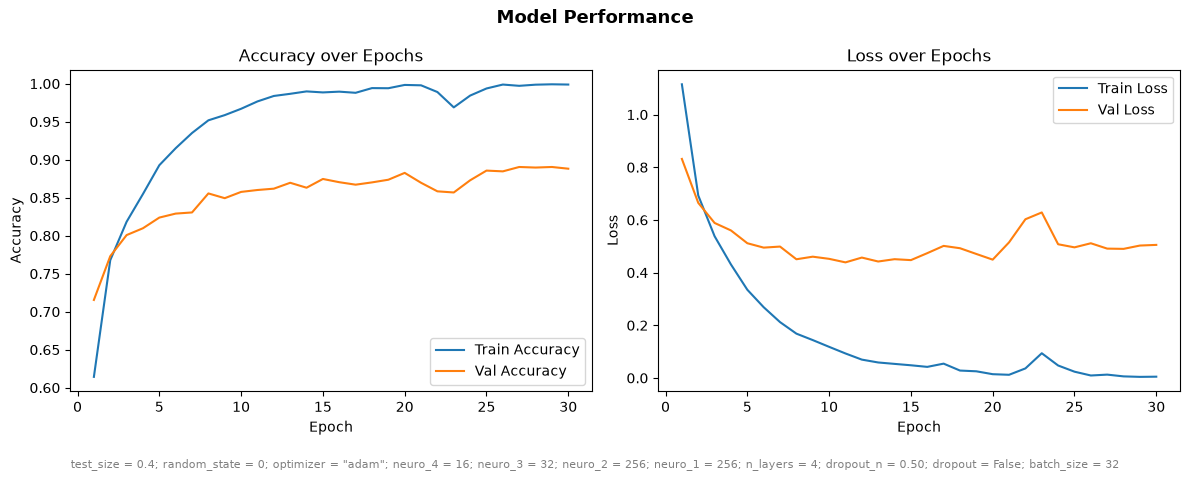

In [40]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history['accuracy']) + 1)

config_str = (
    "test_size = 0.4; random_state = 0; optimizer = \"adam\"; neuro_4 = 16; neuro_3 = 32; neuro_2 = 256; neuro_1 = 256; n_layers = 4; dropout_n = 0.50; dropout = False; batch_size = 32"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history.history['accuracy'], label='Train Accuracy')
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_title('Accuracy over Epochs')

axes[1].plot(epochs_range, history.history['loss'], label='Train Loss')
axes[1].plot(epochs_range, history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].set_title('Loss over Epochs')

# main title
fig.suptitle('Model Performance', fontsize=13, fontweight='bold')

# config caption underneath, small and unobtrusive
fig.text(0.5, -0.02, config_str, ha='center', va='top', fontsize=8, color='gray', wrap=True)

plt.tight_layout()
plt.savefig("ann-model-3.png", bbox_inches='tight', dpi=150)  # bbox_inches='tight' keeps the caption from getting cut off
plt.show()